# Customer Churn Predition: Data Cleaning

**Objective:** Transform raw transactional data into a clean, reliable dataset suitable for churn modeling.
This notebook focuses on structural, semantic, and business-level data validation.

- Dataset: [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)

## 1. Setup

Load required libraries and raw dataset.

**Dataset Context:** The Online Retail II dataset originates from a UK-based e-commerce retailer. UK customers dominate the transaction volume (confirmed in EDA notebook). This context informs cleaning decisions such as return window thresholds.

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Set visualization theme
sns.set_theme(style="whitegrid")

In [2]:
data_sheets = pd.read_excel('../data/raw/online_retail_II.xlsx',sheet_name=None)
retail_df = pd.concat([data_sheets['Year 2009-2010'],data_sheets['Year 2010-2011']],ignore_index=True)

## 2. Initial Data Audit
Understand structure and detect quality issues.

### 2.1 Structure & Schema

In [3]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [4]:
retail_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


### 2.2 Missing Values

In [5]:
print(f"Missing values:\n{retail_df.isnull().sum()}")

Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [6]:
dataset_size = len(retail_df)
missing_descriptions = retail_df['Description'].isnull().sum() / dataset_size
missing_customer_ids =  retail_df['Customer ID'].isnull().sum() / dataset_size
print(f"Missing descriptions: {missing_descriptions:.1%}")
print(f"Missing customer IDS: {missing_customer_ids:.1%}")

Missing descriptions: 0.4%
Missing customer IDS: 22.8%


### 2.3 Duplicates

In [7]:
print(f"Duplicate rows: {retail_df.duplicated().sum()}")

Duplicate rows: 34335


### 2.4 Invalid Transactions & Internal Adjustments

Identify transactions with negative quantities or cancellation invoice patterns. 
These may represent product returns rather than new purchases and must be evaluated before modeling.

**Note:** In this dataset, returns are encoded as negative `Quantity` values while retaining positive `Price`. This convention allows us to distinguish legitimate returns from administrative or system-generated entries, which often have zero or invalid prices.

In [8]:
retail_df[(retail_df['Invoice'].str.startswith('C')) | (retail_df['Quantity'] < 0)].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


Most negative quantity records are associated with 'C'-prefixed invoices, indicating customer-initiated returns.

Now, let's test the inverse: are there any negative quantity transactions not flagged as cancellations?

In [9]:
retail_df[(~retail_df['Invoice'].astype(str).str.startswith('C')) & (retail_df['Quantity'] < 0)].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom


**Findings**:
- Several negative quantity records exist without cancellation invoice codes
- These share common characteristics:
    - Price = 0.0 (no monetary value)
    - Missing Customer ID (no customer association)
    - Descriptions containing terms like 'check', 'lost', 'missing', 'short', 'smashed'

Since these records lack customer association and don't reflect customer purchasing behavior, they must be excluded from customer-level analysis to avoid distorting return rates and engagement metrics.

**Cleaning Approach**:
These internal adjustment records will be removed during the cleaning phase, as they provide no signal for customer behavior modeling.

## 3. Cleaning Strategy

To ensure valid customer-level modeling:

- **Drop missing descriptions** (0.4% of data). These records provide no product-level information and have negligible impact on dataset size.
- **Remove transactions without Customer ID** (22.8%). These likely represent guest purchases and cannot be used for churn modeling, as customer behavior cannot be tracked over time.
- **Remove exact duplicate records.** These are likely system artifacts and provide no additional signal.
- **Exclude internal stock adjustments.** Records with `Price = 0` and negative `Quantity` represent inventory corrections (e.g., 'lost', 'missing', 'smashed'), not customer transactions. These entries do not reflect customer behavior and are removed to avoid distortion of return rates and engagement metrics.
- **Exclude transactions with non-positive prices.** Legitimate returns have positive prices; zero or negative prices indicate administrative entries or data errors.
- **Standardize data types** for consistency and memory efficiency.
- **Retain negative quantities and encode cancellation behavior** using a binary indicator. These capture customer return activity, which is a valuable behavioral signal.

## 4. Data Cleaning Implementation

### 4.1 Remove Invalid Records

In [10]:
initial_count = len(retail_df)
# Remove missing descriptions and customer IDs
retail_df = retail_df.dropna(subset=['Description'])
retail_df = retail_df.dropna(subset=['Customer ID'])

# Remove duplicate rows
retail_df = retail_df.drop_duplicates()

# Remove internal stock adjustments
# These are identified by: Price = 0, negative Quantity, and no Customer ID
# (Customer ID is already filtered, so this primarily catches any remaining adjustments)
internal_adjustments = (retail_df['Price'] == 0) & (retail_df['Quantity'] < 0)
print(f"Removing {internal_adjustments.sum():,} internal stock adjustment records")

retail_df = retail_df[~internal_adjustments]

# Remove remaining non-positive prices (including zero-price records not caught above)
# Note: Returns have positive prices, so this doesn't affect legitimate returns
retail_df = retail_df[retail_df['Price'] > 0]

Removing 0 internal stock adjustment records


In [11]:
print(f"Cleaning complete: {len(retail_df):,} records retained ({len(retail_df)/initial_count:.1%} of original)")

Cleaning complete: 797,815 records retained (74.7% of original)


### 4.2 Standardize Data Types & Formatting

In [12]:
retail_df["Invoice"] = retail_df["Invoice"].astype(str).str.strip()
retail_df["StockCode"] = retail_df["StockCode"].astype(str).str.strip()
retail_df["Description"] = retail_df["Description"].astype(str).str.strip().str.upper()
retail_df["InvoiceDate"] = pd.to_datetime(retail_df["InvoiceDate"])
retail_df["Country"] = retail_df["Country"].astype("category")

retail_df['CustomerID'] = retail_df["Customer ID"].astype(int).astype(str) # Convert to int first to avoid float string notation
retail_df = retail_df.drop(columns=['Customer ID'])

### 4.3 Transaction Status Encoding

In [13]:
retail_df['IsCancelled'] = retail_df['Quantity'] < 0

## 5. Behavioral Transaction Labeling

To better model customer behavior, transactions are classified into meaningful categories.

Using stock code patterns, quantity matching, and temporal logic, transactions are labeled as:

- Standard Purchase  
- System Void (quick corrections)  
- Linked Return (intentional return)  
- Unlinked Return  
- Administrative / Non-product transactions  

**Note on Unlinked Returns:**  
These represent negative transactions without a reconciled original purchase within the defined window. They may result from limited historical visibility, missing customer identifiers in original purchases, or partial/split return transactions that prevent exact quantity reconciliation.

### 5.1 Administrative Mapping

Stock codes containing only letters (non-numeric) represent administrative transactions rather than physical products. These include postage, discounts, manual adjustments, and system entries. Labeling them separately ensures they don't contaminate customer behavior metrics like purchase frequency or average order value.

In [14]:
only_letter_stockcode = retail_df["StockCode"].str.contains(r"^\D+$", regex=True)

retail_df[only_letter_stockcode] \
    .groupby(['StockCode','Description'])[['StockCode','Description']] \
    .value_counts()

StockCode     Description                        
ADJUST        ADJUSTMENT BY JOHN ON 26/01/2010 16      36
              ADJUSTMENT BY JOHN ON 26/01/2010 17      22
              ADJUSTMENT BY PETER ON 24/05/2010 1       3
BANK CHARGES  BANK CHARGES                             37
CRUK          CRUK COMMISSION                          16
D             DISCOUNT                                170
DOT           DOTCOM POSTAGE                           16
M             MANUAL                                 1078
PADS          PADS TO MATCH ALL CUSHIONS               18
POST          POSTAGE                                1983
Name: count, dtype: int64

In [15]:
# Map non-numeric stock codes to descriptive administrative categories
admin_type_mapping = {
    'POST': 'Postage',
    'M': 'Manual',
    'D': 'Discount',
    'ADJUST': 'Adjustment',
    'BANK CHARGES': 'Bank Charges',
    'PADS': 'Pads',
    'DOT': 'Dotcom Postage',
    'CRUK': 'CRUK Commission'
}

### 5.2 Return Matching Logic

This step identifies candidate matches between return transactions and prior purchases based on customer and product identity. When multiple matches exist, the closest prior transaction is selected to approximate real return behavior.

In [16]:
positives = retail_df[retail_df['Quantity'] > 0].copy()
negatives = retail_df[retail_df['Quantity'] < 0].copy()

# Merge on CustomerID + StockCode
matched_pairs = pd.merge(
    negatives,
    positives,
    on=['CustomerID', 'StockCode'],
    suffixes=('_cancel', '_orig')
)

# Keep only valid temporal matches
matched_pairs = matched_pairs[
    matched_pairs['InvoiceDate_orig'] < matched_pairs['InvoiceDate_cancel']
]

# Compute time difference
matched_pairs['time_diff'] = (
    matched_pairs['InvoiceDate_cancel'] - 
    matched_pairs['InvoiceDate_orig']
).dt.total_seconds() / 60

# Keep closest match
matched_pairs = matched_pairs.sort_values('time_diff') \
                             .drop_duplicates(subset=['Invoice_cancel'], keep='first')

### 5.3 Temporal Separation

Differentiate quick system voids from intentional returns using time-difference analysis.

**Return Window Selection**

A 30-day (720-hour) return window is imposed when matching cancellations to original purchases. This constraint serves two purposes:

1. **Aligns with business reality:** Standard retail return policies in the UK (where the majority of transactions originate, as will be shown in the EDA notebook) typically allow 14-30 days for customer returns. The 30-day window captures legitimate returns while excluding stale matches that would likely represent unrelated repeat purchases rather than actual returns.

2. **Prevents misclassification:** Without this constraint, a customer who purchases the same item multiple times over several months could have a cancellation incorrectly matched to a distant original purchase, creating false return linkages.

**Void Detection:** Transactions canceled within 60 minutes of the original purchase are classified as `System_Void`. This threshold captures immediate order corrections (e.g., wrong quantity, accidental purchase) while excluding intentional returns that require customer reflection time.

In [17]:
# Convert 30 days to minutes
max_return_window = 30 * 24 * 60

# System voids: corrections within 60 minutes (e.g., accidental purchases)
# This threshold captures immediate cancellations vs. intentional returns
void_invoices = matched_pairs[
    (matched_pairs['time_diff'] > 0) &
    (matched_pairs['time_diff'] <= 60)
]['Invoice_cancel'].unique()

# Identify linked returns (> 60 minutes)
linked_return_invoices = matched_pairs[
    (matched_pairs['time_diff'] > 60) &
    (matched_pairs['time_diff'] <= max_return_window)
]['Invoice_cancel'].unique()

### 5.4 Unified Transaction Labeling
Create a consolidated `TransactionType` variable based on administrative mapping and return logic.

In [18]:
# Map administrative labels
admin_labels = retail_df['StockCode'].map(admin_type_mapping)

# Define classification rules
conditions = [
    retail_df['StockCode'].isin(admin_type_mapping.keys()),
    retail_df['Invoice'].isin(void_invoices),
    retail_df['Invoice'].isin(linked_return_invoices),
    retail_df['IsCancelled'] == True
]

choices = [
    admin_labels,
    'System_Void',
    'Linked_Return',
    'Unlinked_Return'
]

retail_df['TransactionType'] = np.select(
    conditions,
    choices,
    default='Standard_Purchase'
)
retail_df['TransactionType'] = retail_df['TransactionType'].astype('category')

### 5.5 Transaction Type Distribution
Validate class distribution to ensure logical consistency.

In [19]:
retail_df['TransactionType'].value_counts()

TransactionType
Standard_Purchase    776840
Linked_Return         11906
Unlinked_Return        4350
Postage                1983
System_Void            1340
Manual                 1078
Discount                170
Adjustment               61
Bank Charges             37
Pads                     18
CRUK Commission          16
Dotcom Postage           16
Name: count, dtype: int64

The distribution confirms that standard purchases dominate, with returns and administrative transactions forming smaller, controlled subsets.

### 5.6 Transaction Types Over Time

Validating temporal consistency is critical to ensure the transaction labeling logic doesn't introduce time-dependent biases. The following three visualizations examine transaction type distributions across the dataset's timeframe.

#### Transaction Volume

The stacked area chart below shows raw transaction counts over time. Standard purchases dominate volume, with a clear seasonal pattern: transactions increase sharply during Q4 (October-December) and decline in Q1. This aligns with typical holiday shopping behavior and confirms the dataset captures realistic business cycles.

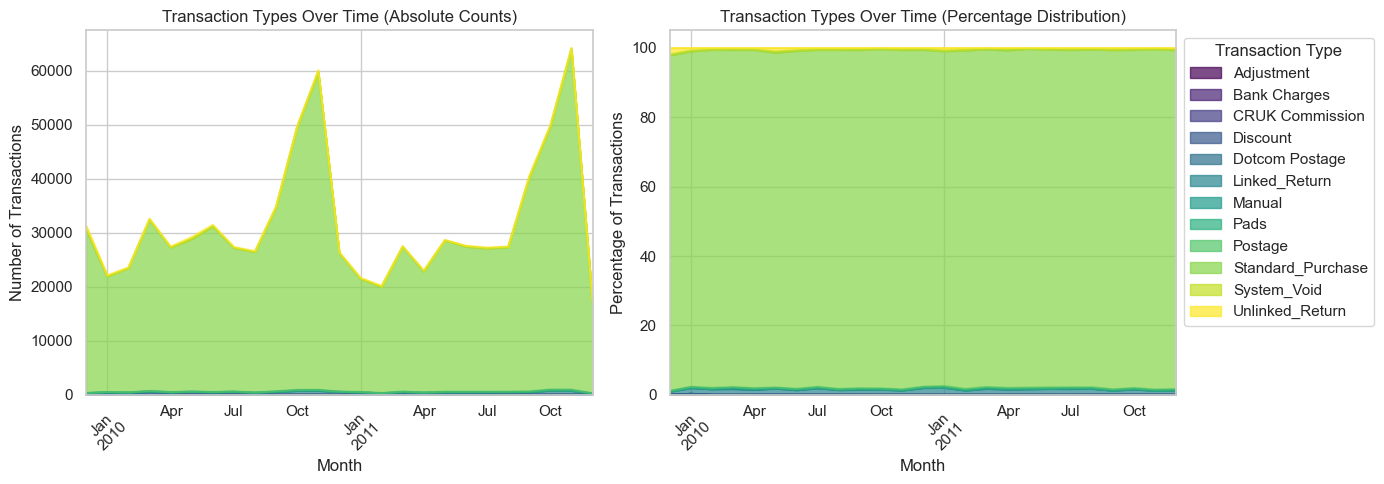

In [58]:
transaction_type_df = retail_df.copy()
# Create monthly aggregation of transaction types
transaction_type_df['YearMonth'] = transaction_type_df['InvoiceDate'].dt.to_period('M')
monthly_txn_types = transaction_type_df.groupby(['YearMonth', 'TransactionType'], observed=False).size().unstack(fill_value=0)

# Normalize to percentage for clearer comparison
monthly_txn_types_pct = monthly_txn_types.div(monthly_txn_types.sum(axis=1), axis=0) * 100

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute counts
monthly_txn_types.plot(kind='area', stacked=True, ax=axes[0], colormap='viridis', alpha=0.7, legend=False)
axes[0].set_title('Transaction Types Over Time (Absolute Counts)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(axis='x', rotation=45)

# Relative percentages
monthly_txn_types_pct.plot(kind='area', stacked=True, ax=axes[1], colormap='viridis', alpha=0.7)
axes[1].set_title('Transaction Types Over Time (Percentage Distribution)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Percentage of Transactions')
axes[1].legend(title='Transaction Type', bbox_to_anchor=(1, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Non-Standard transaction volume

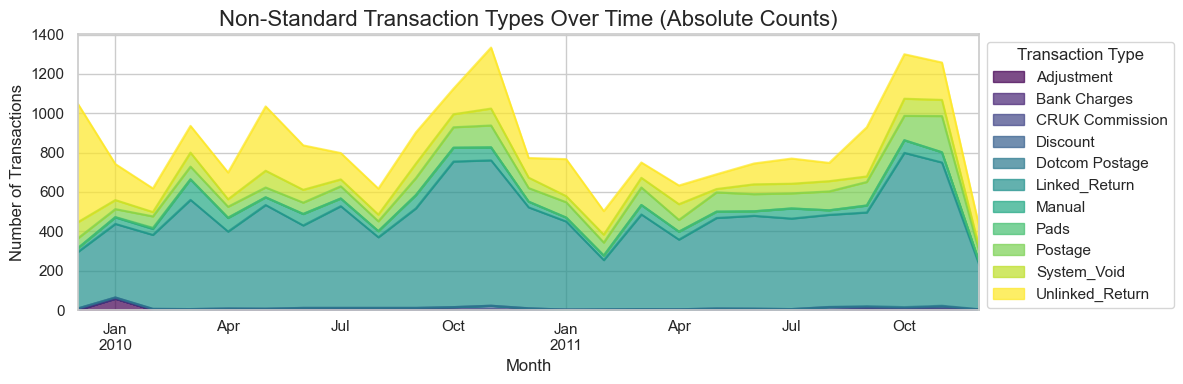

In [59]:
non_standard = monthly_txn_types.drop(columns=['Standard_Purchase'])

non_standard.plot(
    kind='area',
    stacked=True,
    colormap='viridis',
    alpha=0.7,
    figsize=(12, 4)
)

plt.title('Non-Standard Transaction Types Over Time (Absolute Counts)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.legend(title='Transaction Type', bbox_to_anchor=(1, 1), loc='upper left')

plt.tight_layout()
plt.show()

The temporal patterns reveal:
- Strong seasonal signal — Q4 spikes across all transaction types, confirming realistic business cycles
- Stable baseline — Non-Q4 periods show consistent volumes with no unexplained drift
- Proportional consistency — Relative composition remains stable even during peak periods

This stability validates the labeling logic for downstream feature engineering and modeling. The seasonal Q4 pattern itself is valuable signal for churn prediction, as it captures meaningful customer purchasing behavior.

## 6. Outlier Assessment

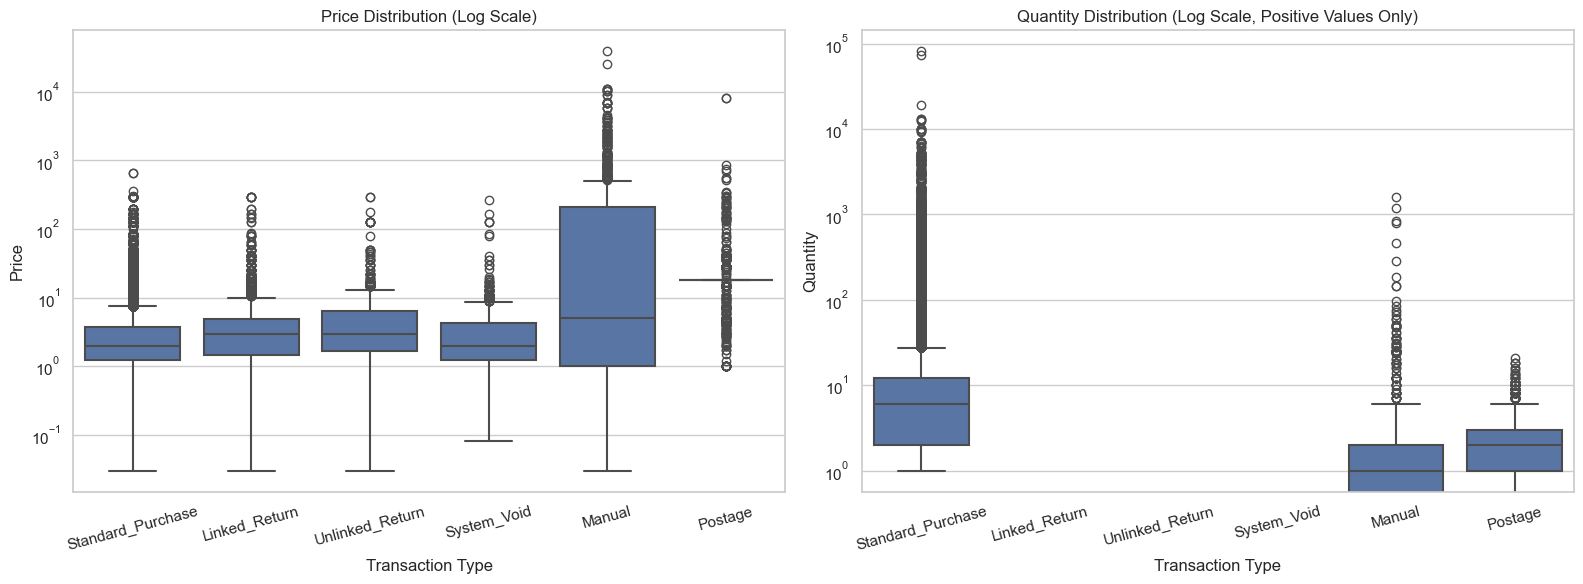

In [22]:
order = [
    "Standard_Purchase",
    "Linked_Return",
    "Unlinked_Return",
    "System_Void",
    "Manual",
    "Postage"
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=retail_df,
    x="TransactionType",
    y="Price",
    order=order,
    linewidth=1.5,
    ax=axes[0]
)

axes[0].set_yscale("log")
axes[0].set_title("Price Distribution (Log Scale)")
axes[0].set_xlabel("Transaction Type")
axes[0].set_ylabel("Price")
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(
    data=retail_df,
    x="TransactionType",
    y="Quantity",
    order=order,
    linewidth=1.5,
    ax=axes[1]
)

axes[1].set_yscale("log")
axes[1].set_title("Quantity Distribution (Log Scale, Positive Values Only)")
axes[1].set_xlabel("Transaction Type")
axes[1].set_ylabel("Quantity")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

Extreme values are observed in `Price`, as illustrated in the boxplot.
Outlier behavior is also present in `Quantity`; however, due to negative values in return and system transactions, only a subset of transaction types can be visualized on a log scale.

Several key observations can be made:
- **High-price outliers** are present across all transaction types, indicating a heavy-tailed distribution.
- **Manual** transactions exhibit the widest spread and most extreme values, suggesting the presence of irregular or exceptional cases (e.g., adjustments or administrative entries).
- **Standard purchases and returns (linked/unlinked)** show more compact distributions, though still containing notable high-value outliers.
- **Postage and system-generated** transactions also display outliers, generally less extreme than manual entries.

From the `Quantity` perspective:
- **Standard purchases** show significant high-value outliers, consistent with bulk (B2B) purchasing behavior.
- **Manual** transactions again exhibit extreme values, reinforcing their association with non-standard operations.

These outliers are not necessarily noise:
- Extreme values in `Price` and `Quantity` may reflect legitimate bulk transactions.
- Outliers are often associated with specific transaction types, particularly administrative or manual operations.

For this reason, outliers are retained to preserve important behavioral signals.

## 7. Data Validation
Run integrity checks to ensure all cleaning and labeling rules were correctly applied before exporting the dataset.

In [23]:
assert retail_df['CustomerID'].isnull().sum() == 0, \
    "Missing CustomerIDs found."

assert retail_df['Description'].isnull().sum() == 0, \
    "Missing Descriptions found."

assert (retail_df['Price'] > 0).all(), \
    "Non-positive prices detected."

internal_adjustments_remaining = retail_df[
    (retail_df['Price'] == 0) & (retail_df['Quantity'] < 0)
]
assert len(internal_adjustments_remaining) == 0, \
    f"Found {len(internal_adjustments_remaining)} internal adjustment records still present."

unlabeled_negatives = retail_df[
    (retail_df['Quantity'] < 0) &
    (retail_df['TransactionType'] == 'Standard_Purchase')
]

assert len(unlabeled_negatives) == 0, \
    f"{len(unlabeled_negatives)} negative transactions were not properly categorized."

# Type Checks
assert pd.api.types.is_datetime64_any_dtype(retail_df['InvoiceDate']), \
    "InvoiceDate is not datetime type."

assert retail_df['TransactionType'].dtype.name == 'category', \
    "Transaction_Type should be categorical."

print("All data integrity checks passed.")

All data integrity checks passed.


## 8. Dataset summary and finalization

Prepare the cleaned dataset for downstream notebooks.

- Compute transaction-level total value.
- Export dataset in an efficient storage format.

In [24]:
# Compute total transaction value
retail_df['TotalSum'] = retail_df['Quantity'] * retail_df['Price']

In [25]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 797815 entries, 0 to 1067370
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Invoice          797815 non-null  object        
 1   StockCode        797815 non-null  object        
 2   Description      797815 non-null  object        
 3   Quantity         797815 non-null  int64         
 4   InvoiceDate      797815 non-null  datetime64[ns]
 5   Price            797815 non-null  float64       
 6   Country          797815 non-null  category      
 7   CustomerID       797815 non-null  object        
 8   IsCancelled      797815 non-null  bool          
 9   TransactionType  797815 non-null  category      
 10  TotalSum         797815 non-null  float64       
dtypes: bool(1), category(2), datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 57.1+ MB


In [26]:
retail_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Country,CustomerID,IsCancelled,TransactionType,TotalSum
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,United Kingdom,13085,False,Standard_Purchase,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,United Kingdom,13085,False,Standard_Purchase,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,United Kingdom,13085,False,Standard_Purchase,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,United Kingdom,13085,False,Standard_Purchase,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,United Kingdom,13085,False,Standard_Purchase,30.0


In [27]:
# Save cleaned dataset
retail_df.to_parquet('../data/processed/online_retail_cleaned.parquet', index=False)